In [4]:
!pip install -q chromadb sentence-transformers scikit-learn matplotlib langchain langchain-community langchain-chroma langchain-huggingface

In [5]:
from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient

In [7]:
# Free 384-dimensional embedding model
embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

print('Embedding dimension:', embed.get_sentence_embedding_dimension())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


Embedding dimension: 384


In [8]:
from pathlib import Path

file_path = Path('/content/sample_data/syllabi_cached/cse_sem5.txt')

with open(file_path, 'r', encoding='utf-8') as f:
    text = f.read()

# Split into paragraphs
paragraphs = [p.strip() for p in text.split('\n\n') if p.strip()][:10]

print(f'Loaded {len(paragraphs)} paragraphs\n')

for i, p in enumerate(paragraphs):
    print(f'[{i+1}] {p[:80]}')

Loaded 7 paragraphs

[1] CSE Semester 5 — Syllabus Excerpt
[2] Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF
[3] Database Management Systems:
ER model, relational model, normalisation (1NF thro
[4] Computer Networks:
OSI and TCP/IP models. Physical, data link, network, transpor
[5] Software Engineering:
SDLC models: waterfall, agile, scrum.
Requirements enginee
[6] Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular 
[7] Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospit


In [9]:
client = PersistentClient(path='./chroma_db')

collection = client.get_or_create_collection(
    name='hello_syllabus'
)

print('Collection ready')

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Collection ready


In [14]:
vectors = embed.encode(paragraphs).tolist()

collection.add(
    documents=paragraphs,
    embeddings=vectors,
    ids=[f'p{i}' for i in range(len(paragraphs))]
)

print(f'Indexed {collection.count()} documents')

Indexed 7 documents


In [15]:
queries = [
    'operating system processes',
    'machine learning topics',
    'what is dynamic programming?'
]

for q in queries:
    print(f'\nQuery: {q}')

    q_embedding = embed.encode([q]).tolist()

    results = collection.query(
        query_embeddings=q_embedding,
        n_results=3
    )

    docs = results['documents'][0]
    distances = results['distances'][0]

    for i, (doc, dist) in enumerate(zip(docs, distances)):
        print(f'[{i+1}] Distance={dist:.3f}')
        print(doc[:100])
        print()

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Query: operating system processes
[1] Distance=0.713
Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF, Round Robin, Prior

[2] Distance=1.246
Database Management Systems:
ER model, relational model, normalisation (1NF through BCNF).
SQL: DDL,

[3] Distance=1.370
Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospital management system


Query: machine learning topics
[1] Distance=1.300
Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular languages.
Context-f

[2] Distance=1.526
Lab work:
OS lab: implement scheduling algorithms in C.
DBMS lab: build a hospital management system

[3] Distance=1.533
Operating Systems:
Process management, threads, scheduling algorithms (FCFS, SJF, Round Robin, Prior


Query: what is dynamic programming?
[1] Distance=1.464
Theory of Computation:
Finite automata (DFA, NFA), regular expressions, regular languages.
Context-f

[2] Distance=1.469
Lab work:
OS lab: implement sc

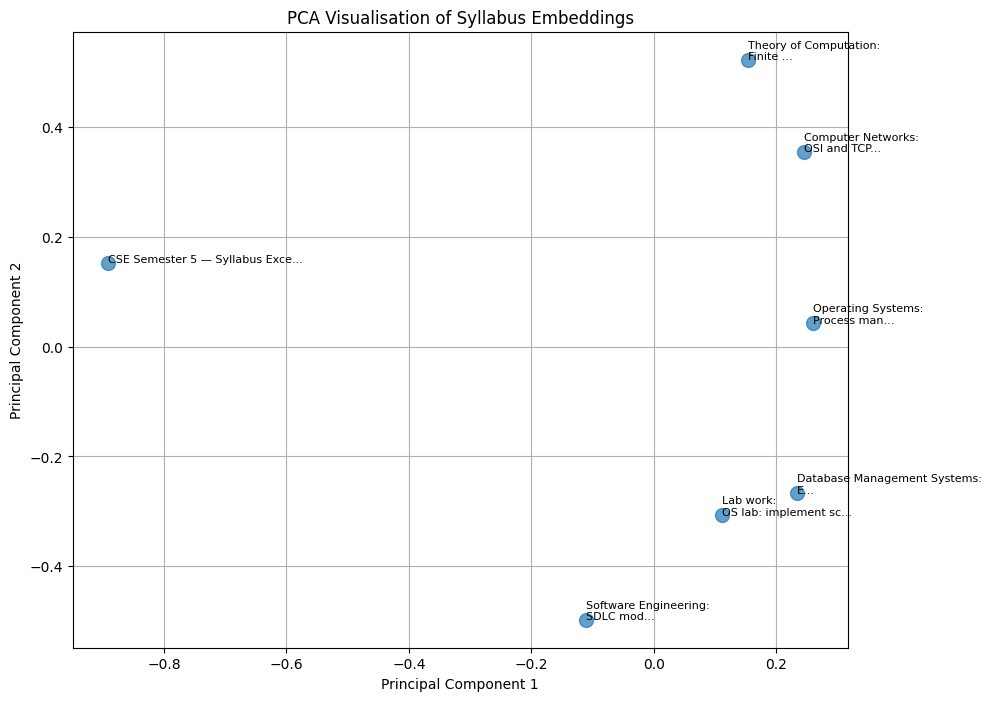

In [16]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

vectors_array = np.array(vectors)

pca = PCA(n_components=2)
xy = pca.fit_transform(vectors_array)

plt.figure(figsize=(10, 8))

plt.scatter(xy[:, 0], xy[:, 1], s=100, alpha=0.7)

for i, paragraph in enumerate(paragraphs):
    label = paragraph[:30] + '...'
    plt.annotate(label, (xy[i, 0], xy[i, 1]), fontsize=8)

plt.title('PCA Visualisation of Syllabus Embeddings')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionGetEvent: capture() takes 1 positional argument but 3 were given


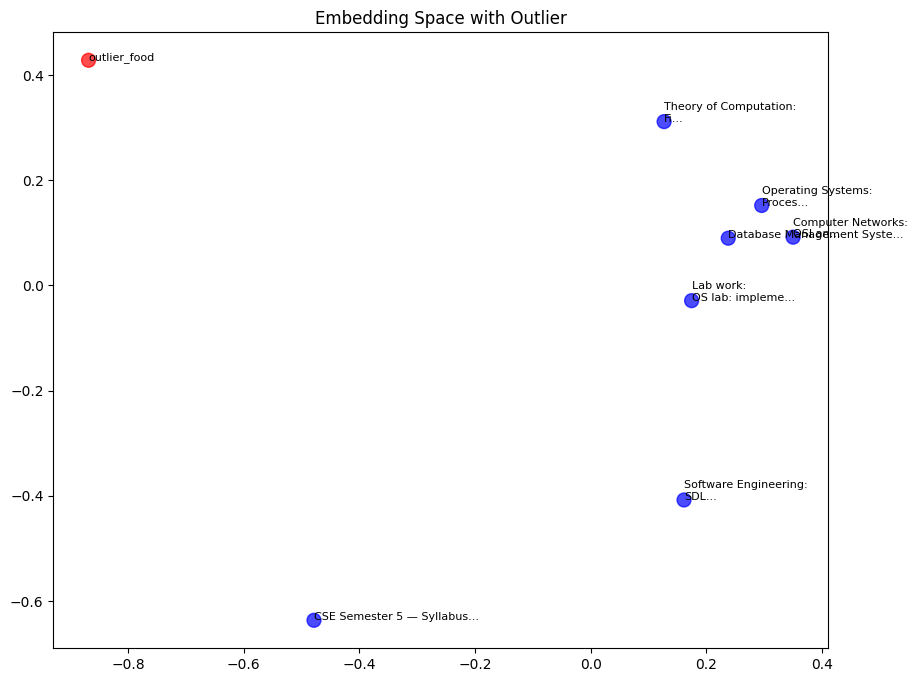

In [17]:
outlier = 'Today special at the cafeteria is butter chicken with naan and rice.'

collection.add(
    documents=[outlier],
    embeddings=embed.encode([outlier]).tolist(),
    ids=['outlier_food']
)

all_docs = collection.get(include=['embeddings', 'documents'])

all_vectors = np.array(all_docs['embeddings'])
labels = all_docs['ids']

pca = PCA(n_components=2)
xy = pca.fit_transform(all_vectors)

plt.figure(figsize=(10, 8))

colors = ['red' if 'outlier' in label else 'blue' for label in labels]

plt.scatter(xy[:, 0], xy[:, 1], c=colors, s=100, alpha=0.7)

for i, label in enumerate(labels):
    text = label if 'outlier' in label else all_docs['documents'][i][:25] + '...'
    plt.annotate(text, (xy[i, 0], xy[i, 1]), fontsize=8)

plt.title('Embedding Space with Outlier')
plt.show()

In [18]:
!pip install -q \
pydantic==2.7.4 \
langchain==0.2.17 \
langchain-core==0.2.43 \
langchain-community==0.2.19 \
langchain-chroma==0.1.4 \
langchain-google-genai==1.0.10 \
langchain-huggingface==0.0.3 \
langchain-text-splitters==0.2.4 \
chromadb==0.5.3 \
sentence-transformers==3.0.1 \
pypdf

In [ ]:
!pip install -q protobuf==4.25.3

In [19]:
!pip install -q \
numpy==1.26.4 \
scipy==1.13.1 \
scikit-learn==1.5.1 \
sentence-transformers==2.7.0 \
transformers==4.41.2 \
protobuf==4.25.3 \
google-generativeai==0.7.2 \
chromadb==0.5.3 \
langchain==0.2.17 \
langchain-core==0.2.43 \
langchain-community==0.2.19 \
langchain-chroma==0.1.4 \
langchain-google-genai==1.0.10 \
langchain-huggingface==0.0.3 \
langchain-text-splitters==0.2.4 \
pydantic==2.7.4 \
pypdf

In [20]:
import numpy
import scipy
import sklearn

print(numpy.__version__)
print(scipy.__version__)
print(sklearn.__version__)

1.26.4
1.13.1
1.5.1


In [21]:
from sentence_transformers import SentenceTransformer

print("SentenceTransformers OK")

SentenceTransformers OK


In [22]:
from chromadb import PersistentClient

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain.prompts import PromptTemplate
from langchain.chains import RetrievalQA

print("All imports successful")

All imports successful


In [23]:
from sentence_transformers import SentenceTransformer
from chromadb import PersistentClient
from langchain.text_splitter import RecursiveCharacterTextSplitter
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain.chains import RetrievalQA
from langchain.prompts import PromptTemplate

import json
import pathlib
import os

print("All imports successful")

All imports successful


In [24]:
embed = SentenceTransformer('sentence-transformers/all-MiniLM-L6-v2')

client = PersistentClient(path='./chroma_db')

collection = client.get_or_create_collection('placement_kb')

print('Starting count:', collection.count())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Starting count: 0


In [25]:
vectors = embed.encode(["Hello world"]).tolist()

collection.add(
    documents=["Hello world"],
    embeddings=vectors,
    ids=["test1"]
)

print("New count:", collection.count())

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


New count: 1


In [26]:
all_jds = []

cached_path = pathlib.Path('/content/sample_data/jds_cached.jsonl')

for line in cached_path.read_text().splitlines():
    all_jds.append(json.loads(line))

own_path = pathlib.Path('data/jds.jsonl')

if own_path.exists():
    for line in own_path.read_text().splitlines():
        all_jds.append(json.loads(line))

print('Total JDs:', len(all_jds))

for i, jd in enumerate(all_jds):

    text = (
        f"{jd['company']} - {jd['role']}: "
        f"must-have skills: {', '.join(jd['must_have_skills'])}. "
        f"locations: {', '.join(jd.get('locations', []))}. "
        f"package: {jd.get('package_lpa', 'N/A')} LPA"
    )

    collection.add(
        documents=[text],
        embeddings=embed.encode([text]).tolist(),
        ids=[f'jd_{i}'],
        metadatas=[{
            'type': 'jd',
            'company': jd['company']
        }]
    )

print('Indexed JD documents:', collection.count())

Total JDs: 10
Indexed JD documents: 11


In [27]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)

syllabi_dir = pathlib.Path('/content/sample_data/syllabi_cached')

chunk_count = 0

for syllabus_file in syllabi_dir.glob('*.txt'):

    text = syllabus_file.read_text()

    chunks = splitter.split_text(text)

    for j, chunk in enumerate(chunks):

        collection.add(
            documents=[chunk],
            embeddings=embed.encode([chunk]).tolist(),
            ids=[f'{syllabus_file.stem}_{j}'],
            metadatas=[{
                'type': 'syllabus',
                'source': syllabus_file.stem,
                'chunk_index': j
            }]
        )

        chunk_count += 1

print('Indexed syllabus chunks:', chunk_count)
print('Total documents:', collection.count())

Indexed syllabus chunks: 15
Total documents: 26


In [28]:
import os, getpass
if 'GEMINI_API_KEY' not in os.environ:
    os.environ['GEMINI_API_KEY'] = getpass.getpass('Gemini API key: ')

Gemini API key: ··········


In [33]:
import chromadb.api.client as chroma_client

# Clear old cached Chroma systems
chroma_client.SharedSystemClient._identifier_to_system.clear()

print("Old Chroma instances cleared")

Old Chroma instances cleared


In [34]:
from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

embedding_function = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

vector_store = Chroma(
    collection_name='placement_kb',
    embedding_function=embedding_function,
    persist_directory='./chroma_db'
)

print("Vector store connected")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vector store connected


In [35]:
import os
os.environ["ANONYMIZED_TELEMETRY"] = "False"

from sentence_transformers import SentenceTransformer

from langchain_chroma import Chroma
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_google_genai import ChatGoogleGenerativeAI

from langchain.prompts import PromptTemplate
from langchain.chains import RetrievalQA

# Embedding model
embed = SentenceTransformer(
    'sentence-transformers/all-MiniLM-L6-v2'
)

embedding_function = HuggingFaceEmbeddings(
    model_name='sentence-transformers/all-MiniLM-L6-v2'
)

# Vector DB
vector_store = Chroma(
    collection_name='placement_kb',
    embedding_function=embedding_function,
    persist_directory='./chroma_db'
)

prompt_template = """
Use ONLY the context below.

Always cite the chunk ID.
Do NOT use outside knowledge.
If answer not found, say: I do not know.

Context:
{context}

Question:
{question}

Answer:
"""

prompt = PromptTemplate.from_template(prompt_template)

# Gemini LLM
llm = ChatGoogleGenerativeAI(
    model='gemini-2.5-flash',
    google_api_key=os.environ['GEMINI_API_KEY']
)

# Retrieval QA
qa = RetrievalQA.from_chain_type(
    llm=llm,
    retriever=vector_store.as_retriever(search_kwargs={'k': 4}),
    chain_type_kwargs={'prompt': prompt},
    return_source_documents=True
)

print("RetrievalQA chain ready")

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


RetrievalQA chain ready


In [36]:
questions = [
    'Which companies require Python?',
    'What are Sem 5 operating system topics?',
    'Companies hiring in Hyderabad?',
    'Which companies need Java and DSA?',
    'What is TCS Codevita?'
]

for q in questions:

    result = qa.invoke({'query': q})

    print('\nQuestion:', q)
    print('Answer:', result['result'])

    print('Sources:')

    for doc in result['source_documents']:
        print(doc.metadata)

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given



Question: Which companies require Python?
Answer: The companies that require Python are:
*   Goldman Sachs (Goldman Sachs - Technology Analyst)
*   Accenture (Accenture - Associate Software Engineer)
*   Cognizant (Cognizant - Programmer Analyst)
Sources:
{'company': 'Goldman Sachs', 'type': 'jd'}
{'company': 'Accenture', 'type': 'jd'}
{'chunk_index': 2, 'source': 'cse_sem6', 'type': 'syllabus'}
{'company': 'Cognizant', 'type': 'jd'}

Question: What are Sem 5 operating system topics?
Answer: Sem 5 operating system topics include: Process management, threads, scheduling algorithms (FCFS, SJF, Round Robin, Priority), Memory management (paging, segmentation, virtual memory, page replacement), File systems (directory structures, file allocation methods), Synchronisation (critical section, semaphores, monitors, classical problems), and Deadlocks (prevention, avoidance (Banker's algorithm), detection, recovery). (CSE Semester 5 — Syllabus Excerpt)
Sources:
{'chunk_index': 0, 'source': 'cse_

In [37]:
questions = [
    'Which companies want Java + DSA + CGPA 7+?',
    'What are the Sem 5 OS topics?',
    'Which JDs require Python?',
    'Top 3 skills appearing across all JDs?',
    'Companies hiring in Hyderabad?',
]

for q in questions:
    result = qa.invoke({'query': q})
    print(f'\nQ: {q}')
    print(f'A: {result["result"]}')
    print(f'Sources: {[d.metadata.get("source") or d.metadata.get("company") for d in result["source_documents"]]}')


Q: Which companies want Java + DSA + CGPA 7+?
A: I do not know.
Sources: ['TCS Digital', 'Goldman Sachs', 'Cognizant', 'Amazon']

Q: What are the Sem 5 OS topics?
A: The Sem 5 OS topics are:
* Process management, threads, scheduling algorithms (FCFS, SJF, Round Robin, Priority). (CSE Semester 5 — Syllabus Excerpt)
* Memory management: paging, segmentation, virtual memory, page replacement. (CSE Semester 5 — Syllabus Excerpt)
* File systems: directory structures, file allocation methods. (CSE Semester 5 — Syllabus Excerpt)
* Synchronisation: critical section, semaphores, monitors, classical problems. (CSE Semester 5 — Syllabus Excerpt)
* Deadlocks: prevention, avoidance (Banker's algorithm), detection, recovery. (CSE Semester 5 — Syllabus Excerpt)
Sources: ['cse_sem5', 'cse_sem5', 'cse_sem6', 'cse_sem6']

Q: Which JDs require Python?
A: The following Job Descriptions require Python:

*   Goldman Sachs - Technology Analyst (Chunk ID: Goldman Sachs - Technology Analyst)
*   Accenture - A